In [1]:
from pathlib import Path
from torch import multiprocessing
from tqdm import tqdm
import soundfile as sf

In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from utils.utils import gen_empty_df
from cfg import get_config

In [5]:
def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_annotations_df,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])
        
    return bd_dets

def apply_models(file_path_mappings, cfg):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a dataframe

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()
    cfg : `dict`
        - A dictionary of pipeline parameters:
        - models is the models in the pipeline that are being used.

    Returns
    ------------
    bd_preds : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    process_pool = multiprocessing.Pool(cfg['num_processes'])

    bd_dets = tqdm(
            process_pool.imap(apply_model, file_path_mappings, chunksize=1), 
            desc=f"Applying BatDetect2",
            total=len(file_path_mappings),
        )
    
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(bd_dets, ignore_index=True)
    
    return bd_preds

def apply_model(file_mapping):
    """
    Runs the batdetect2 model on a single provided audio segmens and corrects the offsets according the segment.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    corrected_bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = file_mapping['model']._run_batdetect(file_mapping['audio_seg']['audio_file'])
    corrected_bd_dets = pipeline._correct_annotation_offsets(
                                                            bd_dets,
                                                            file_mapping['original_file_name'],
                                                            file_mapping['audio_seg']['offset']
                                                            )

    return corrected_bd_dets

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = run_models(file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

def apply_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = apply_models(file_path_mappings, cfg)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

run_pipeline_on_file(input_file, cfg)

Generating detections for 20220728_080000.WAV


100%|██████████| 60/60 [02:54<00:00,  2.91s/it]


,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file
0,0.0135,0.0219,36640,49331,Pipistrellus nathusii,0.539,0.588,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,0.1295,0.1389,37500,48700,Pipistrellus nathusii,0.601,0.626,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,0.2405,0.2484,36640,45200,Pipistrellus nathusii,0.569,0.639,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
3,0.3425,0.3520,36640,49395,Pipistrellus nathusii,0.574,0.613,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
4,0.4485,0.4569,37500,48215,Pipistrellus nathusii,0.651,0.667,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
...,...,...,...,...,...,...,...,...,...,...
86,1794.1435,1794.1580,22890,29234,Nyctalus leisleri,0.488,0.648,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
87,1794.3755,1794.3911,22890,27858,Nyctalus leisleri,0.565,0.629,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
88,1794.6075,1794.6260,22890,27947,Nyctalus leisleri,0.361,0.540,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
89,1794.7165,1794.7290,25468,29839,Nyctalus leisleri,0.611,0.676,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...


In [7]:
def _apply_model(item):
    annotations_df = item['model']._run_batdetect(item['audio_seg']['audio_file'])
    return pipeline._correct_annotation_offsets(
        annotations_df,
        item['original_file_name'],
        item['audio_seg']['offset']
    )

def _apply_models(cfg, audio_segments):
    csv_names = []
    audio_file_path = cfg['audio_file']
    process_pool = multiprocessing.Pool(cfg['num_processes'])

    for model in cfg['models']:

        l_for_mapping = [{
            'audio_seg': audio_seg, 
            'model': model,
            'original_file_name': audio_file_path,
            } for audio_seg in audio_segments]

        pred_dfs = tqdm(
            process_pool.imap(_apply_model, l_for_mapping, chunksize=1), 
            desc=f"Applying {model.get_name()}",
            total=len(l_for_mapping),
        )

        agg_df = gen_empty_df() 
        agg_df = pd.concat(pred_dfs, ignore_index=True)

        csv_name = pipeline._generate_csv(agg_df, model.get_name(),
            audio_file_path.name,
            cfg['output_dir'],
            cfg['should_csv']
        )
        csv_names.append(csv_name)

    return csv_names

In [8]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['audio_file'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 12
cfg['should_csv'] = False
cfg['save'] = True

segmented_file_paths = pipeline._segment_input_audio(cfg)
_apply_models(cfg, segmented_file_paths[:4])

Applying BatDetectorMSDS: 100%|██████████| 4/4 [00:48<00:00, 12.12s/it]


[PosixPath('../output_dir/BatDetectorMSDS-20220728_080000.WAV.txt')]

In [8]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 30.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)

Generating detections for 20220728_080000.WAV


In [13]:
import os
import torch
from bat_detect.detector import models
import bat_detect.utils.detector_utils as du


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if os.path.isfile(file_path_mappings[0]['model'].model_path):
    NET_PARAMS = torch.load(file_path_mappings[0]['model'].model_path, map_location=DEVICE)


def load_model(model_path, load_weights=True):
    params = NET_PARAMS['params']
    params['device'] = DEVICE

    if params['model_name'] == 'Net2DFast':
        model = models.Net2DFast(params['num_filters'], num_classes=len(params['class_names']),
                                 emb_dim=params['emb_dim'], ip_height=params['ip_height'],
                                 resize_factor=params['resize_factor'])
    elif params['model_name'] == 'Net2DFastNoAttn':
        model = models.Net2DFastNoAttn(params['num_filters'], num_classes=len(params['class_names']),
                                 emb_dim=params['emb_dim'], ip_height=params['ip_height'],
                                 resize_factor=params['resize_factor'])
    elif params['model_name'] == 'Net2DFastNoCoordConv':
        model = models.Net2DFastNoCoordConv(params['num_filters'], num_classes=len(params['class_names']),
                                 emb_dim=params['emb_dim'], ip_height=params['ip_height'],
                                 resize_factor=params['resize_factor'])
    else:
        print('Error: unknown model.')

    if load_weights:
        model.load_state_dict(NET_PARAMS['state_dict'])

    model = model.to(params['device'])
    model.eval()

    return model, params

def _run_batdetect(model_obj, audio_file): #
    """
    Parameters:: 
        audio_file: a path containing the post-processed wav file.

    Returns:: a pd.Dataframe containing the bat calls detections
    """
    model, params = load_model(model_obj.model_path)

    # model_output = du.process_file(
    #     audio_file=audio_file, 
    #     model=model, 
    #     params=params, 
    #     args= {
    #         'detection_threshold': model_obj.detection_threshold,
    #         'spec_slices': model_obj.spec_slices,
    #         'chunk_size': model_obj.chunk_size,
    #         'quiet': model_obj.quiet,
    #         'spec_features' : False,
    #         'cnn_features': model_obj.cnn_features,
    #     },
    #     time_exp=model_obj.time_expansion_factor,
    # )
    # annotations = model_output['pred_dict']['annotation']

    out_df = gen_empty_df()
    # if annotations:
    #     out_df = pd.DataFrame.from_records(annotations) 
        # out_df['detection_confidence'] = out_df['det_prob']
        # out_df.drop(columns = ['class', 'class_prob', 'det_prob','individual'], inplace=True)
    return out_df


def apply_model(file_mapping):
    """
    Runs the batdetect2 model on a single provided audio segmens and corrects the offsets according the segment.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    corrected_bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = _run_batdetect(file_mapping['model'], file_mapping['audio_seg']['audio_file'])
    corrected_bd_dets = pipeline._correct_annotation_offsets(
                                                            bd_dets,
                                                            file_mapping['original_file_name'],
                                                            file_mapping['audio_seg']['offset']
                                                            )

    return corrected_bd_dets

In [14]:
input = file_path_mappings[:4]
num_rows = min(len(input), multiprocessing.cpu_count())
num_cols = len(input)
time_taken_test3 = np.zeros((num_rows, num_cols))
for i in range(num_rows):
    for j in range(num_cols):
        num_processes = int(i+1)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = pool.map(apply_model, input, chunksize=chunksize_custom)
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        time_taken_test3[i,j] = end-start

Parsing 4 chunks with 1 processors and 1 chunks per processor
Parsing 4 chunks with 1 processors and 2 chunks per processor
Parsing 4 chunks with 1 processors and 3 chunks per processor
Parsing 4 chunks with 1 processors and 4 chunks per processor
Parsing 4 chunks with 2 processors and 1 chunks per processor
Parsing 4 chunks with 2 processors and 2 chunks per processor
Parsing 4 chunks with 2 processors and 3 chunks per processor
Parsing 4 chunks with 2 processors and 4 chunks per processor
Parsing 4 chunks with 3 processors and 1 chunks per processor
Parsing 4 chunks with 3 processors and 2 chunks per processor
Parsing 4 chunks with 3 processors and 3 chunks per processor
Parsing 4 chunks with 3 processors and 4 chunks per processor
Parsing 4 chunks with 4 processors and 1 chunks per processor
Parsing 4 chunks with 4 processors and 2 chunks per processor
Parsing 4 chunks with 4 processors and 3 chunks per processor
Parsing 4 chunks with 4 processors and 4 chunks per processor


In [15]:
time_taken_test3

array([[0.09815145, 0.09980845, 0.09842968, 0.09855032],
       [0.39651799, 0.24018955, 0.22862482, 0.10686135],
       [0.24847269, 0.30160999, 0.24222398, 0.14176035],
       [0.28855562, 0.24739981, 0.21600914, 0.11017728]])

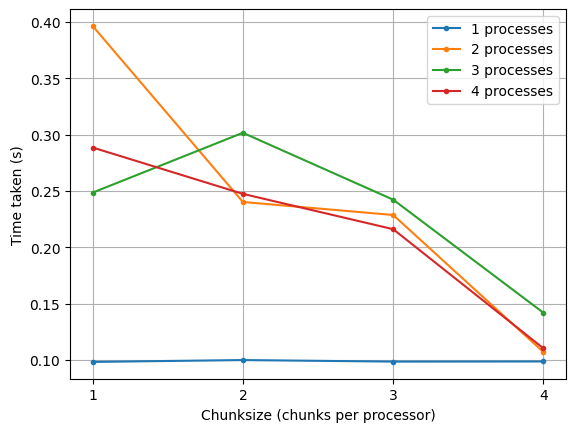

In [16]:
plt.plot(time_taken_test3.T, marker='.')
plt.xticks(range(4), np.arange(4)+1)
plt.xlabel('Chunksize (chunks per processor)')
plt.ylabel('Time taken (s)')
line_labs = []
for p in range(num_rows):
    line_labs+=[f'{int(p+1)} processes']
plt.legend(line_labs)
plt.grid(which='both')
plt.show()